# Output Correlation Experiment — Pangu-Weather (24h)

Строим корреляционную матрицу между выходными переменными модели (4 поверхностных + 5×13 верхних = 69 каналов):

1. Корреляция **сырых полей** и корреляция **аномалий** (climatology вычтена) — сырые поля почти всегда сильно
   коррелируют просто из-за общей широтной/климатической структуры (везде теплее у экватора и т.п.); аномалии
   показывают реальные совместные вариации, а не тривиальный климатический паттерн.
2. То же самое, но на **реальных ERA5** данных (ground truth на valid time = case_time + 24h) — сравнение, какие
   физические связи модель воспроизводит верно, а какие искажает.
3. **Локальные пространственные карты корреляции** для пары физически значимых переменных (не один глобальный
   скаляр) — считаются скользящим окном по одному снимку (пространственная, не временная корреляция).

Переиспользует `baseline_output` из `results/<case>.pkl` (уже посчитан в `02_saliency_experiment.ipynb`,
дополнительных прогонов модели на GPU не требуется).


In [1]:
import pickle
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcParams['figure.dpi'] = 110

PRESSURE_LEVELS_HPA = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50]
SURFACE_ORDER = ['mean_sea_level_pressure', '10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature']
UPPER_ORDER = ['geopotential', 'specific_humidity', 'temperature', 'u_component_of_wind', 'v_component_of_wind']
CASES = ['storm_eunice', 'heatwave_block', 'quiet_baseline']
CASE_DATES = {
    'storm_eunice':   '2022-02-18T12:00',
    'heatwave_block': '2022-07-18T12:00',
    'quiet_baseline': '2021-10-05T12:00',
}


def channel_labels():
    labels = list(SURFACE_ORDER)
    for v in UPPER_ORDER:
        for lvl in PRESSURE_LEVELS_HPA:
            labels.append(f'{v}@{lvl}hPa')
    return labels


CHANNEL_LABELS = channel_labels()
print(f'{len(CHANNEL_LABELS)} channels total')


69 channels total


## 1. Загрузка прогнозов модели (baseline_output) из результатов ноутбука 2


In [2]:
case_results = {}
for case in CASES:
    with open(f'results/{case}.pkl', 'rb') as f:
        case_results[case] = pickle.load(f)


def stack_channels(output_surface, output_upper):
    """Flatten surface (4,721,1440) + upper (5,13,721,1440) into (69, 721*1440)."""
    surf_flat = output_surface.reshape(4, -1)
    upp_flat = output_upper.reshape(5 * len(PRESSURE_LEVELS_HPA), -1)
    return np.concatenate([surf_flat, upp_flat], axis=0)


model_fields = {}
for case in CASES:
    out_surf, out_upp = case_results[case]['baseline_output']
    model_fields[case] = stack_channels(out_surf, out_upp)
    print(case, 'stacked shape:', model_fields[case].shape)


storm_eunice stacked shape: (69, 1038240)
heatwave_block stacked shape: (69, 1038240)


quiet_baseline stacked shape: (69, 1038240)


## 2. Ground truth (ERA5 на valid time = case_time + 24h) и климатология для valid time


In [3]:
ARCO_URL = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
ds_arco = xr.open_zarr(ARCO_URL, storage_options=dict(token='anon'), chunks=None)
ds_arco = ds_arco.assign_coords(longitude=(ds_arco.longitude % 360)).sortby('longitude')

CLIMATOLOGY_YEARS_BACK = 8


def fetch_truth_and_climatology(case_key):
    """Ground truth at valid time, plus climatology (mean over N prior years at the same calendar
    day/hour) computed AT THE VALID TIME (case_time + 24h) — needed to anomalize model output and
    truth consistently, since the model forecasts the state 24h after the input snapshot."""
    valid_time = np.datetime64(CASE_DATES[case_key]) + np.timedelta64(24, 'h')

    truth_snapshot = ds_arco.sel(time=valid_time, method='nearest')
    truth_surface = np.stack([truth_snapshot[v].values for v in SURFACE_ORDER], axis=0).astype(np.float32)
    truth_upper = np.stack(
        [truth_snapshot[v].sel(level=PRESSURE_LEVELS_HPA).values for v in UPPER_ORDER], axis=0).astype(np.float32)

    sample_times = [valid_time - np.timedelta64(365 * i, 'D') for i in range(1, CLIMATOLOGY_YEARS_BACK + 1)]
    surface_samples = ds_arco[SURFACE_ORDER].sel(time=sample_times, method='nearest').load()
    upper_samples = ds_arco[UPPER_ORDER].sel(time=sample_times, method='nearest').sel(level=PRESSURE_LEVELS_HPA).load()
    clim_surface = np.stack([surface_samples[v].mean(dim='time').values for v in SURFACE_ORDER], axis=0).astype(np.float32)
    clim_upper = np.stack([upper_samples[v].mean(dim='time').values for v in UPPER_ORDER], axis=0).astype(np.float32)

    return truth_surface, truth_upper, clim_surface, clim_upper


truth_fields = {}
climatology_fields = {}
for case in CASES:
    print(f'Fetching ground truth + climatology for {case}...')
    truth_surface, truth_upper, clim_surface, clim_upper = fetch_truth_and_climatology(case)
    truth_fields[case] = stack_channels(truth_surface, truth_upper)
    climatology_fields[case] = stack_channels(clim_surface, clim_upper)
print('Done.')


/home/irina/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


/home/irina/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.cloud._storage_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud._storage_v2 past that date.
  warnings.warn(message, FutureWarning)
/home/irina/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:254: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


Fetching ground truth + climatology for storm_eunice...


Fetching ground truth + climatology for heatwave_block...


Fetching ground truth + climatology for quiet_baseline...


Done.


## 3. Корреляционные матрицы: сырые поля vs аномалии, модель vs ground truth


In [4]:
def corr_matrix(fields):
    """fields: (n_channels, n_points) -> (n_channels, n_channels) Pearson correlation."""
    return np.corrcoef(fields)


correlation_results = {}
for case in CASES:
    model_raw = model_fields[case]
    truth_raw = truth_fields[case]
    clim = climatology_fields[case]

    model_anomaly = model_raw - clim
    truth_anomaly = truth_raw - clim

    correlation_results[case] = {
        'model_raw': corr_matrix(model_raw),
        'model_anomaly': corr_matrix(model_anomaly),
        'truth_raw': corr_matrix(truth_raw),
        'truth_anomaly': corr_matrix(truth_anomaly),
    }
    print(f'{case}: correlation matrices computed.')


storm_eunice: correlation matrices computed.


heatwave_block: correlation matrices computed.


quiet_baseline: correlation matrices computed.


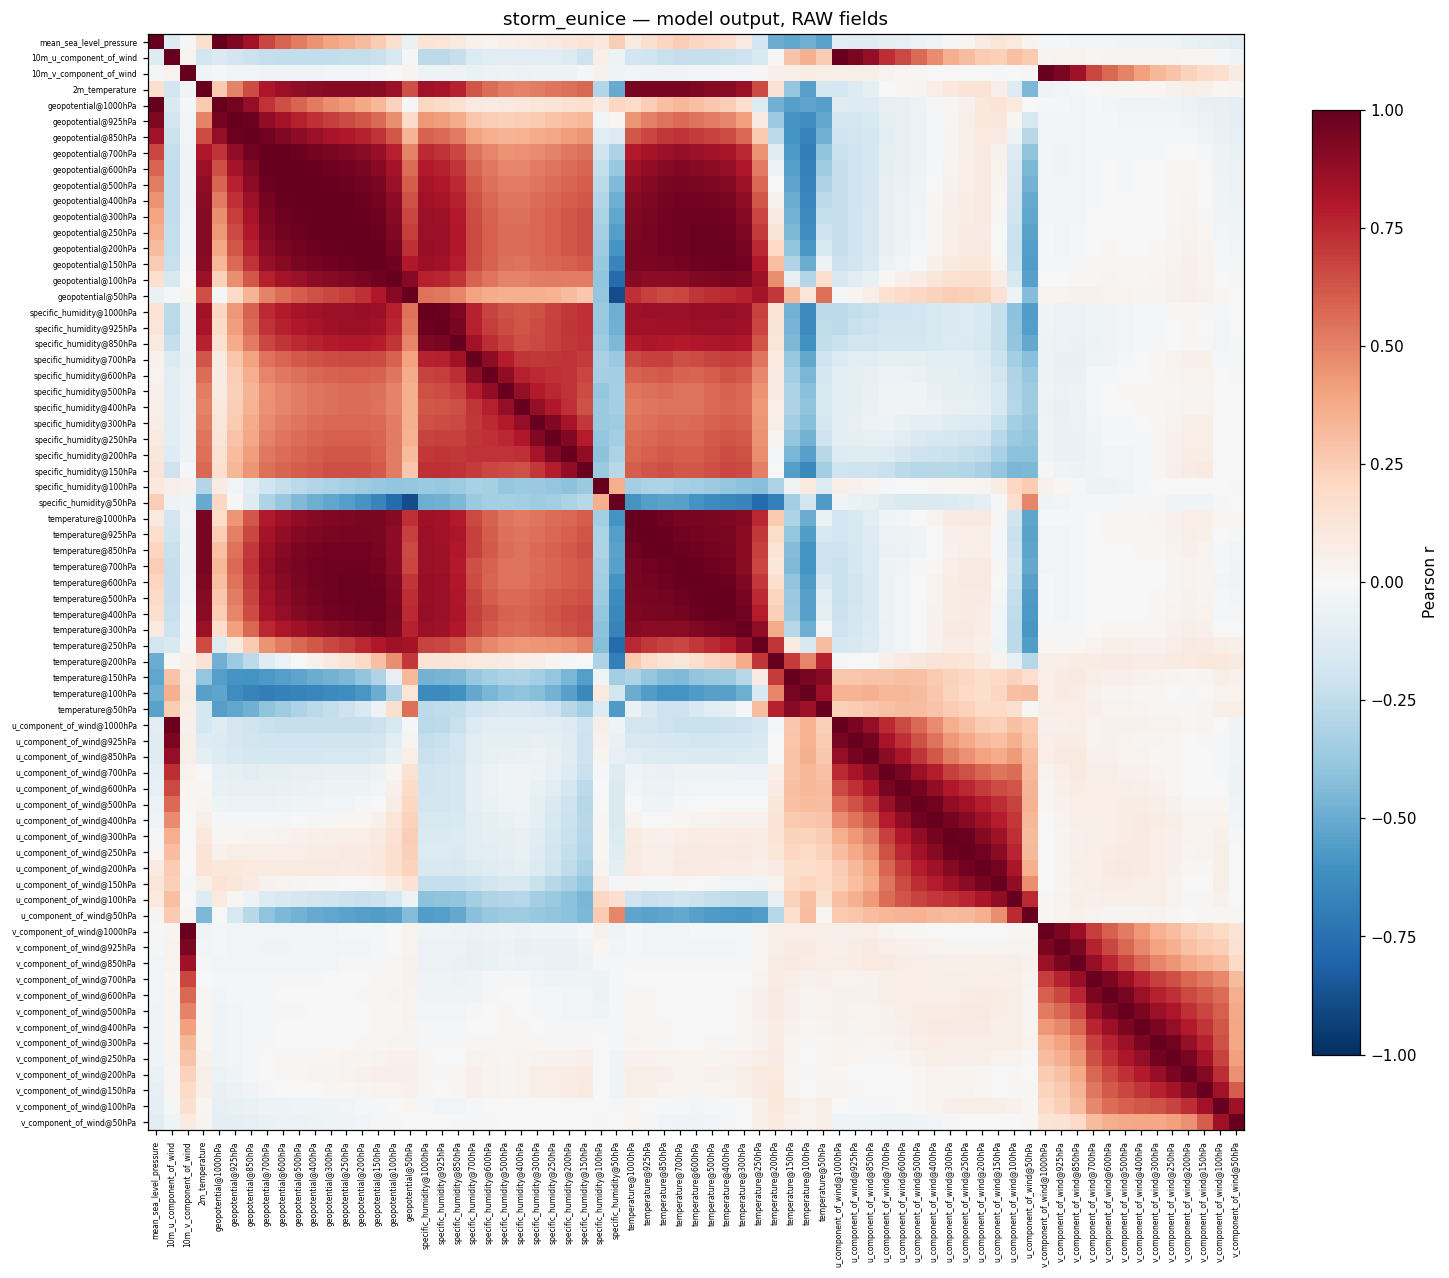

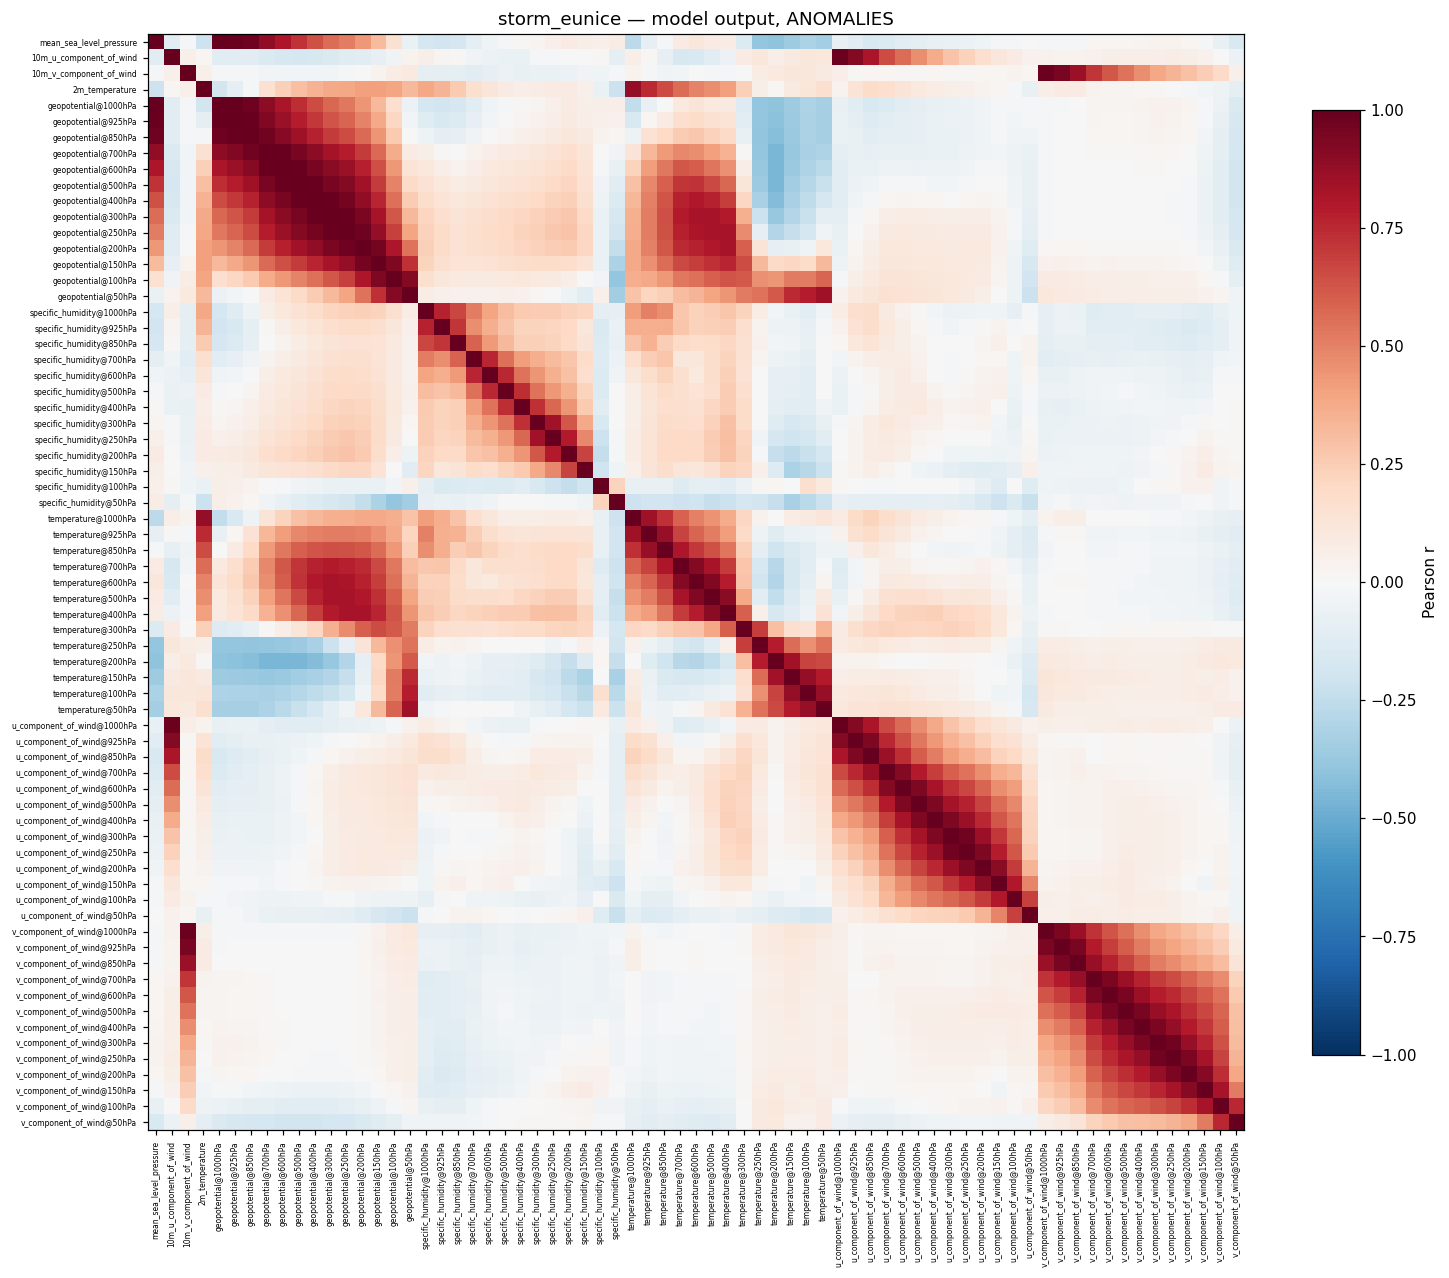

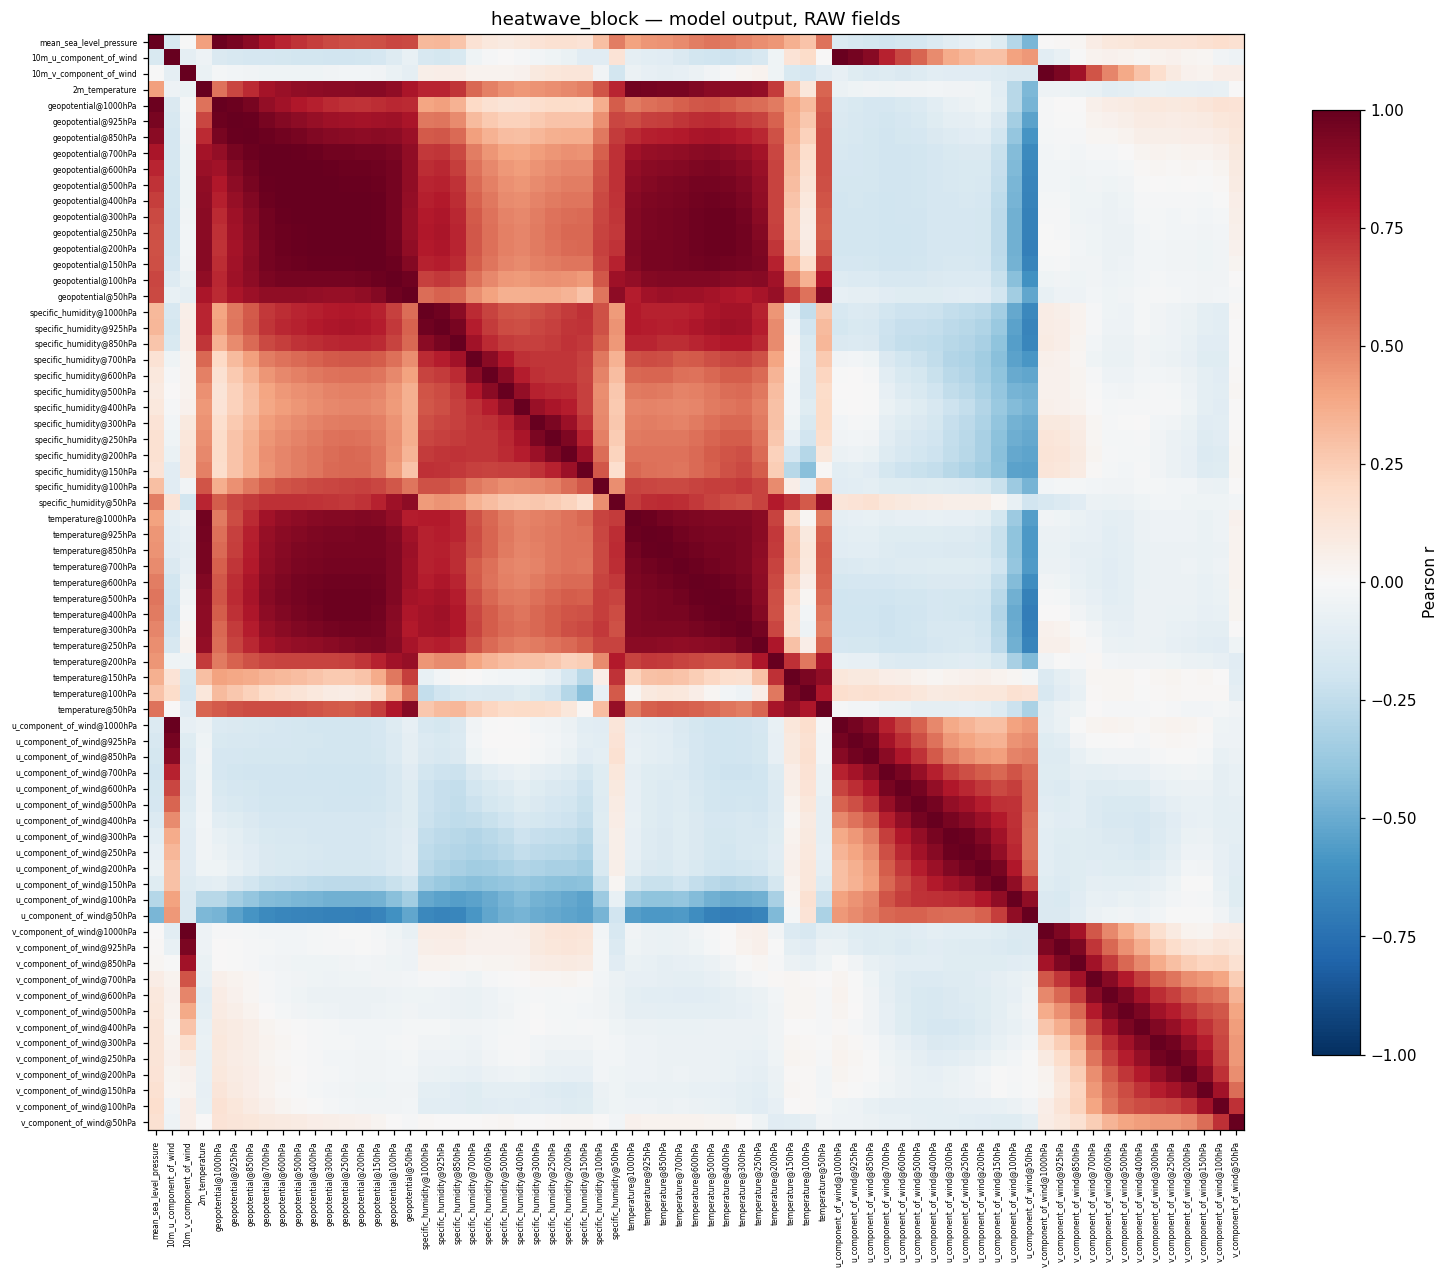

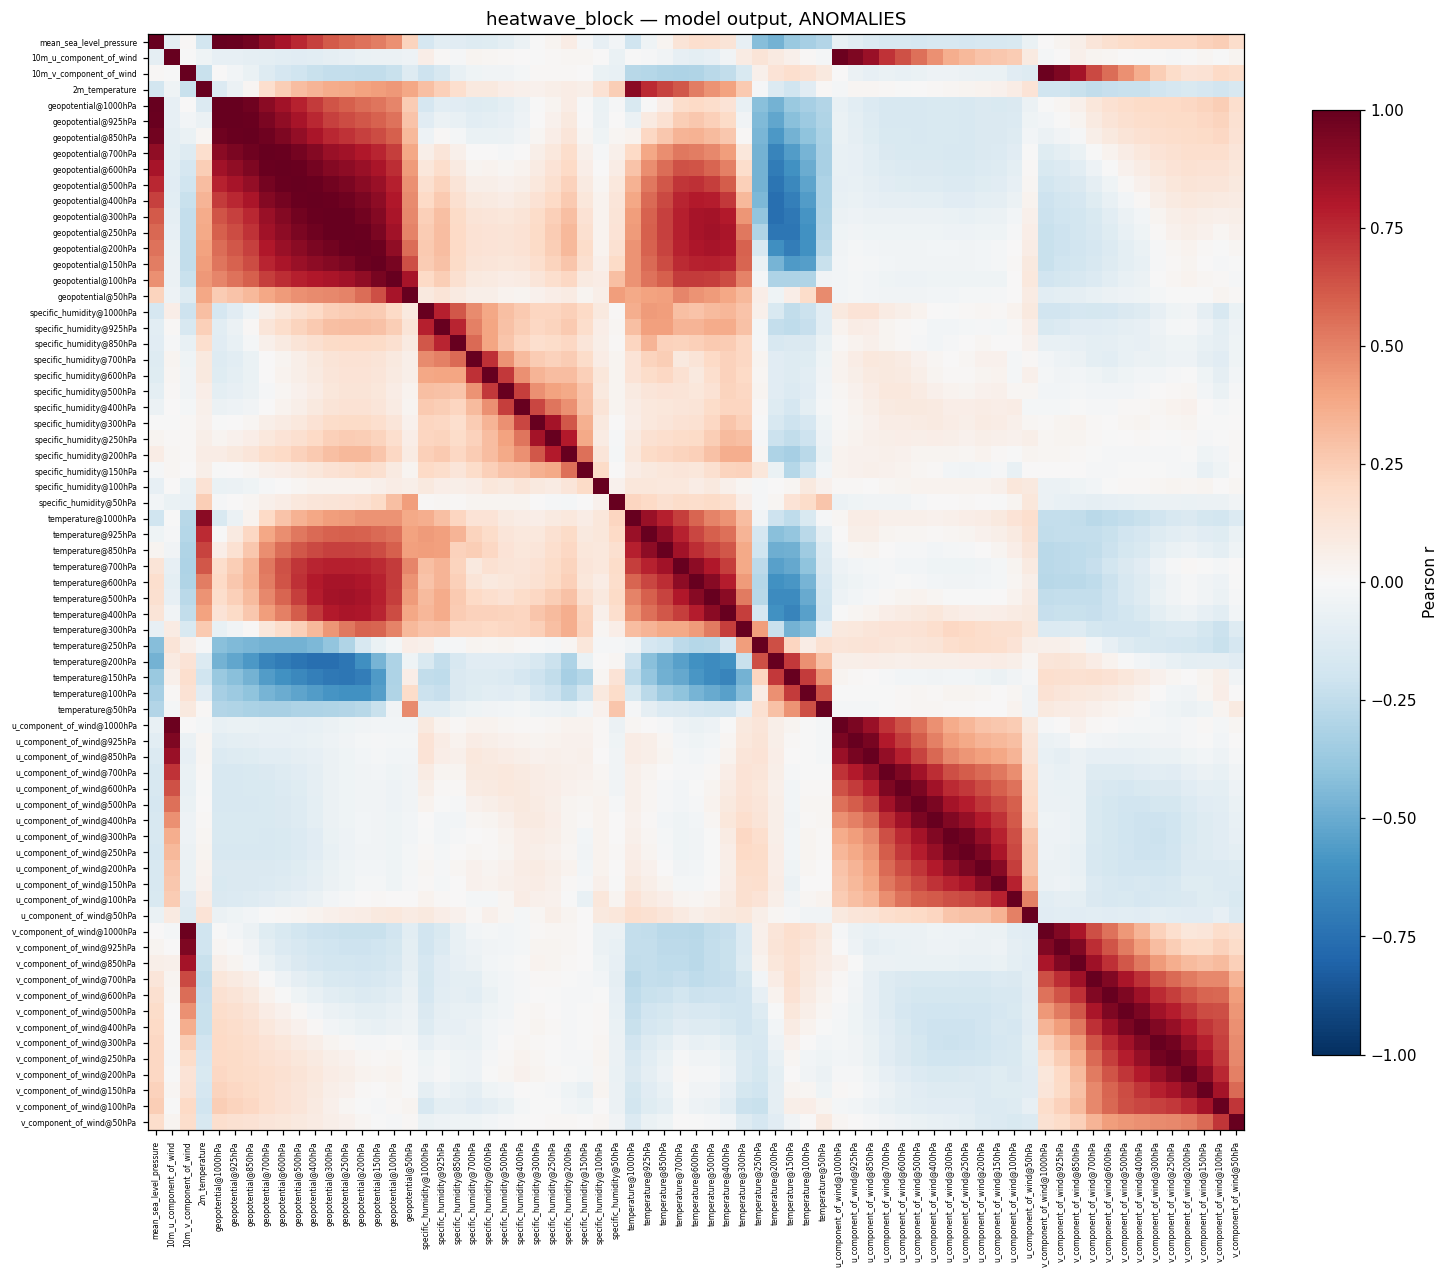

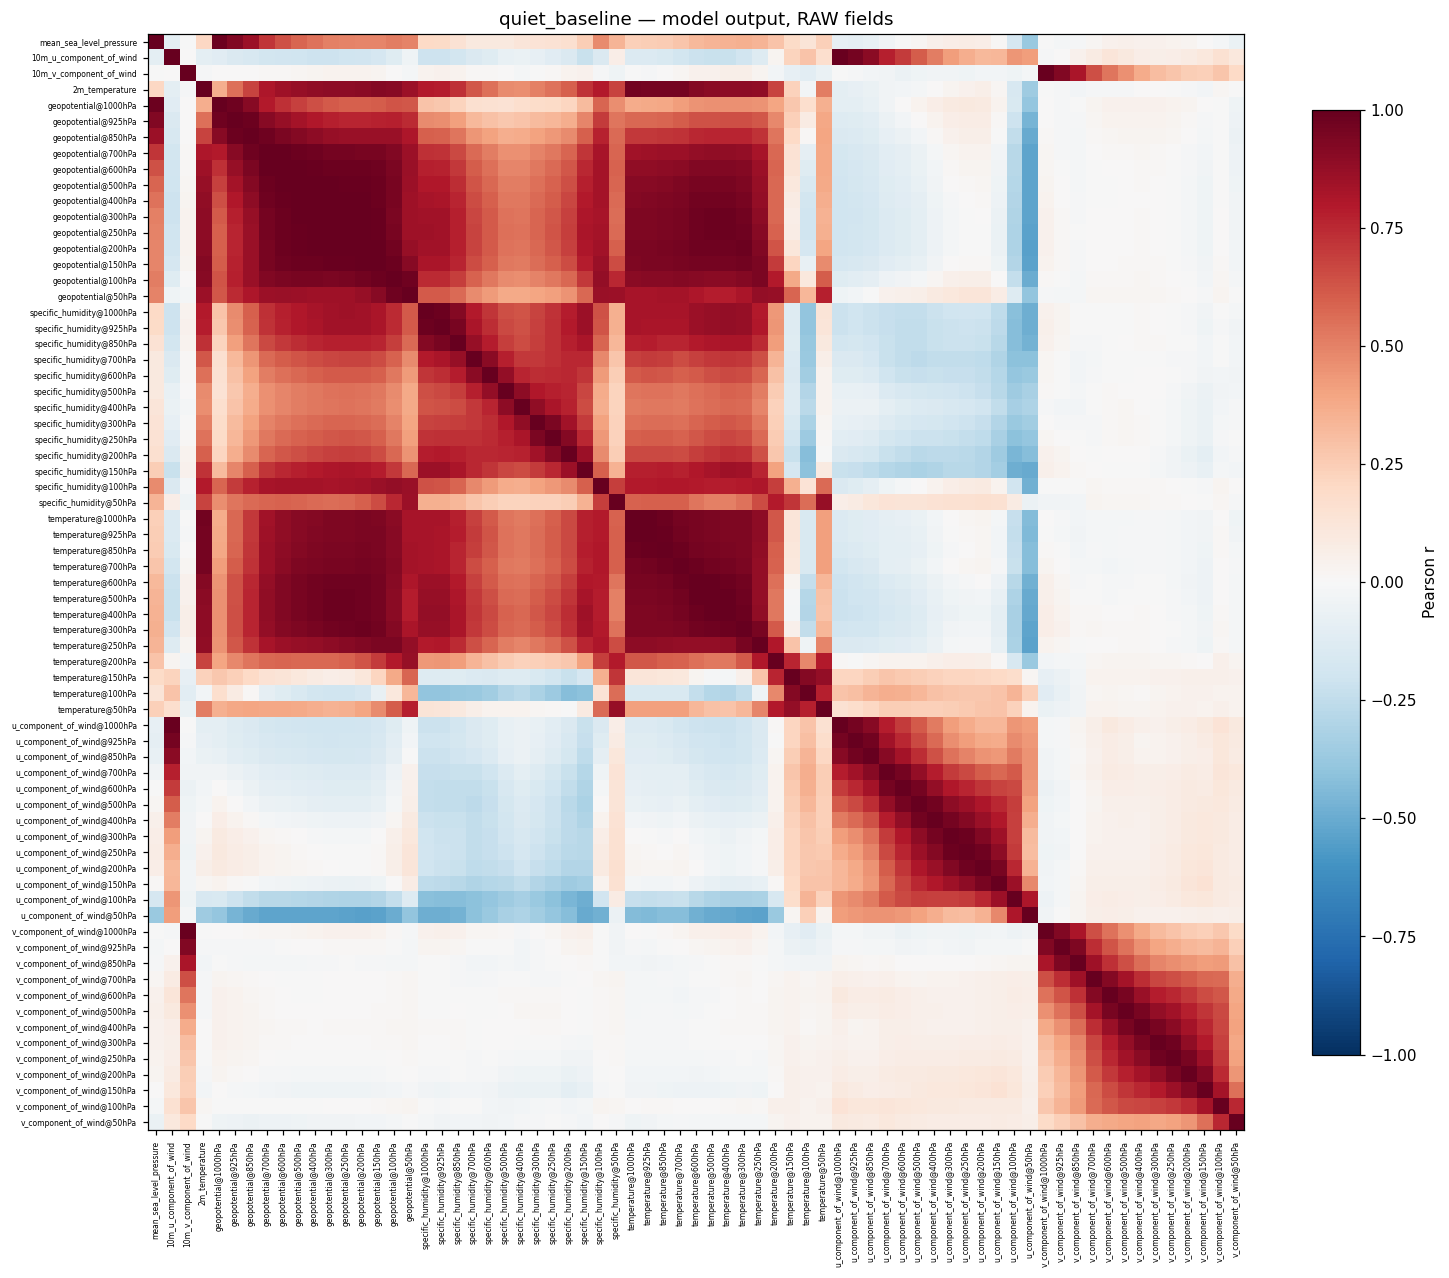

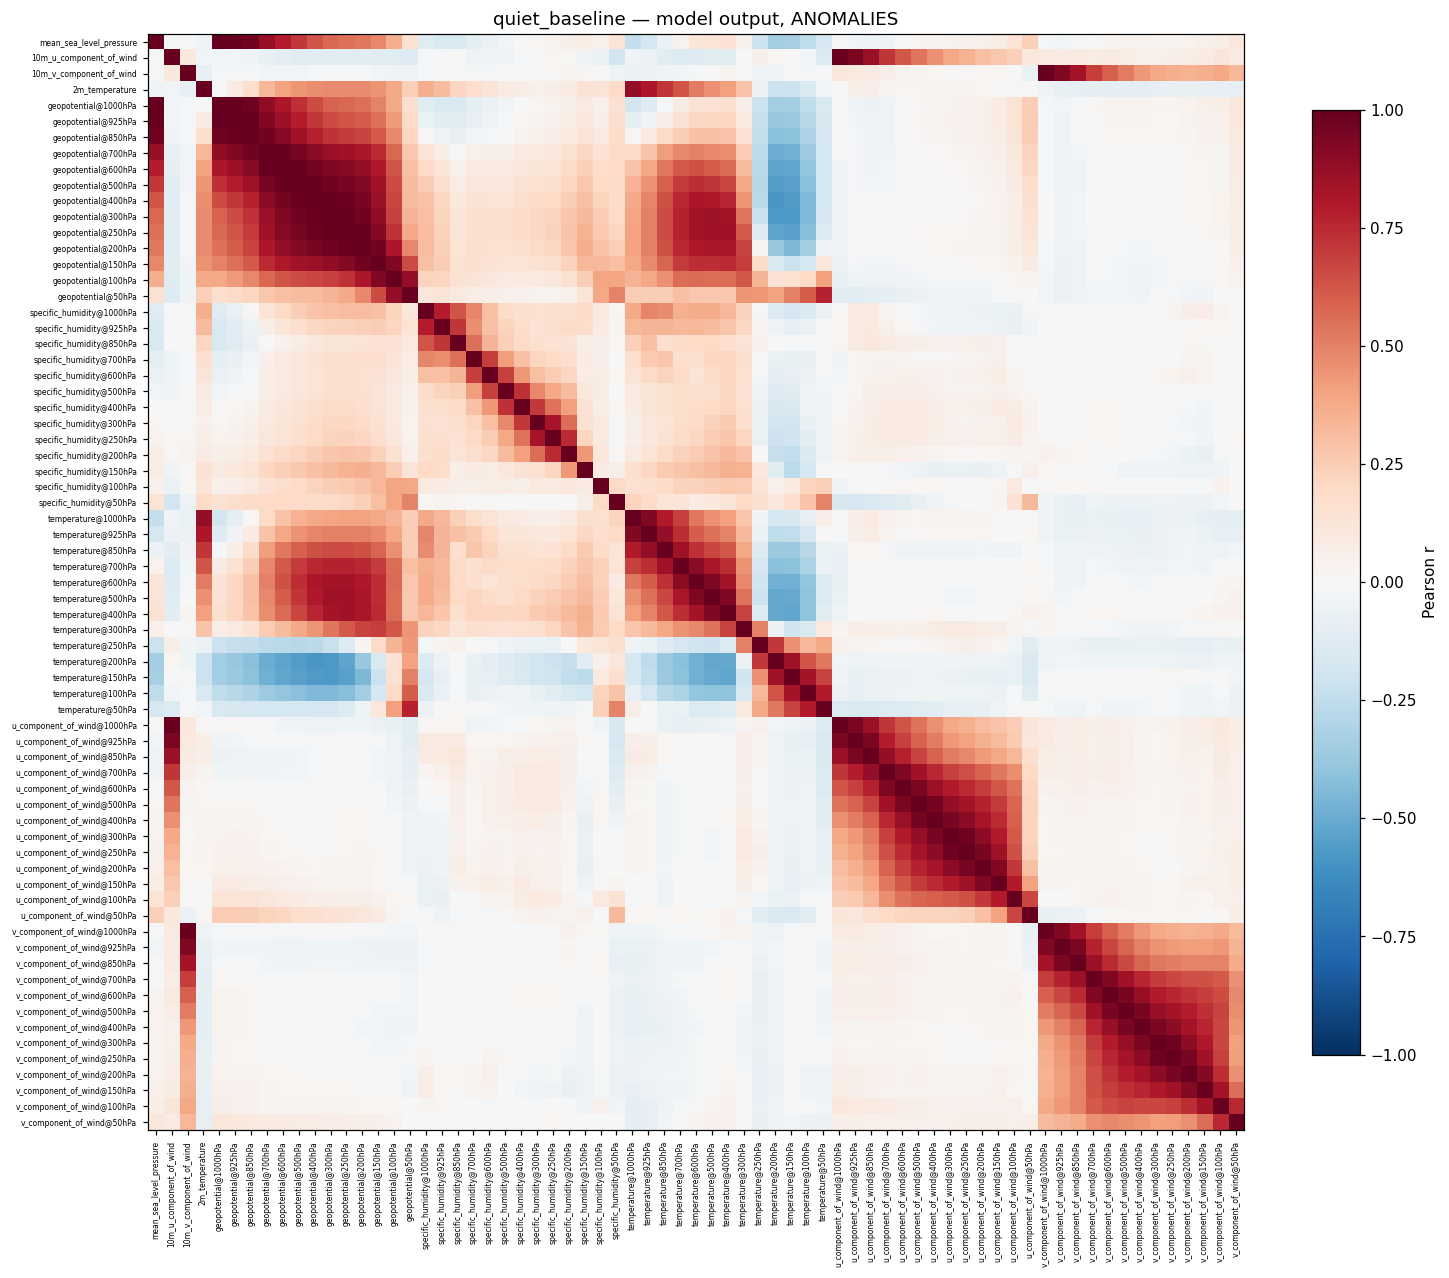

In [5]:
def plot_corr_matrix(matrix, title, filename):
    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(CHANNEL_LABELS)))
    ax.set_yticks(range(len(CHANNEL_LABELS)))
    ax.set_xticklabels(CHANNEL_LABELS, rotation=90, fontsize=5)
    ax.set_yticklabels(CHANNEL_LABELS, fontsize=5)
    plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'figures/{filename}.png', dpi=150, bbox_inches='tight')
    plt.show()


for case in CASES:
    res = correlation_results[case]
    plot_corr_matrix(res['model_raw'], f'{case} — model output, RAW fields', f'{case}_corr_model_raw')
    plot_corr_matrix(res['model_anomaly'], f'{case} — model output, ANOMALIES', f'{case}_corr_model_anomaly')


## 4. Модель vs ground truth: разница корреляционных матриц

Если модель хорошо воспроизводит физику, разница должна быть близка к нулю (сине-белая карта). Крупные красные/синие
пятна — места, где модель либо переоценивает, либо недооценивает реальную физическую связь между переменными.


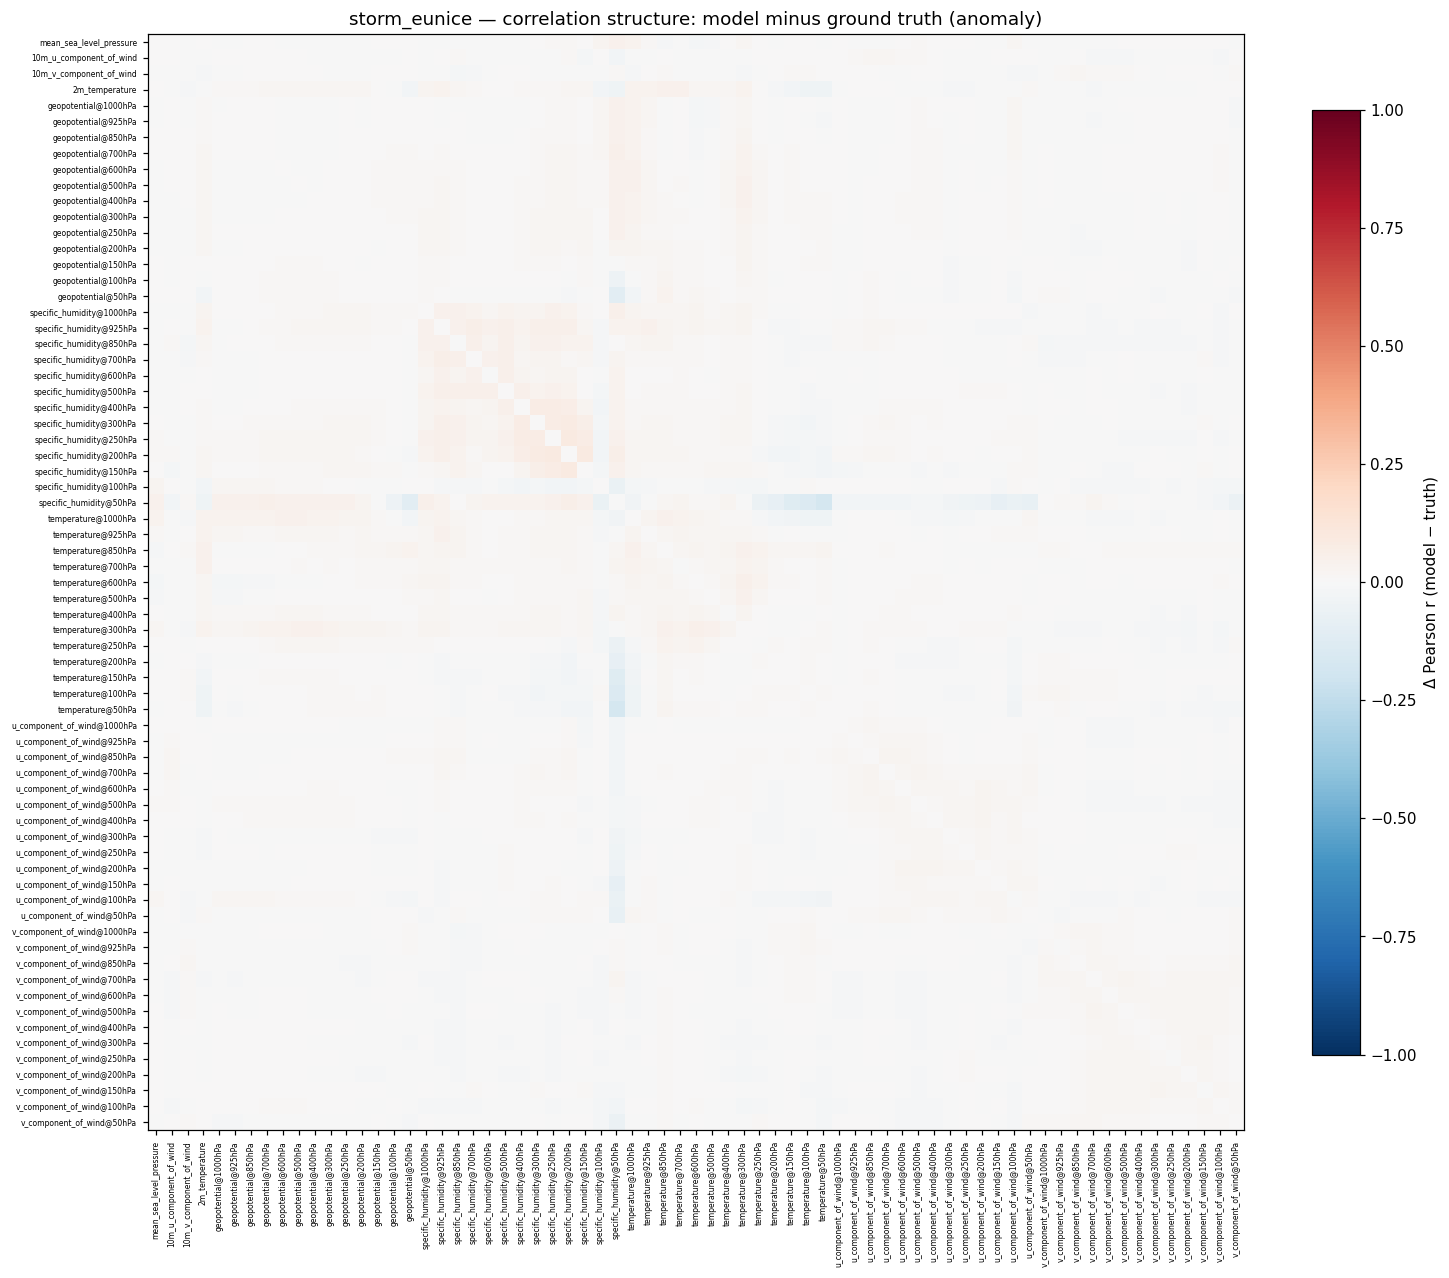

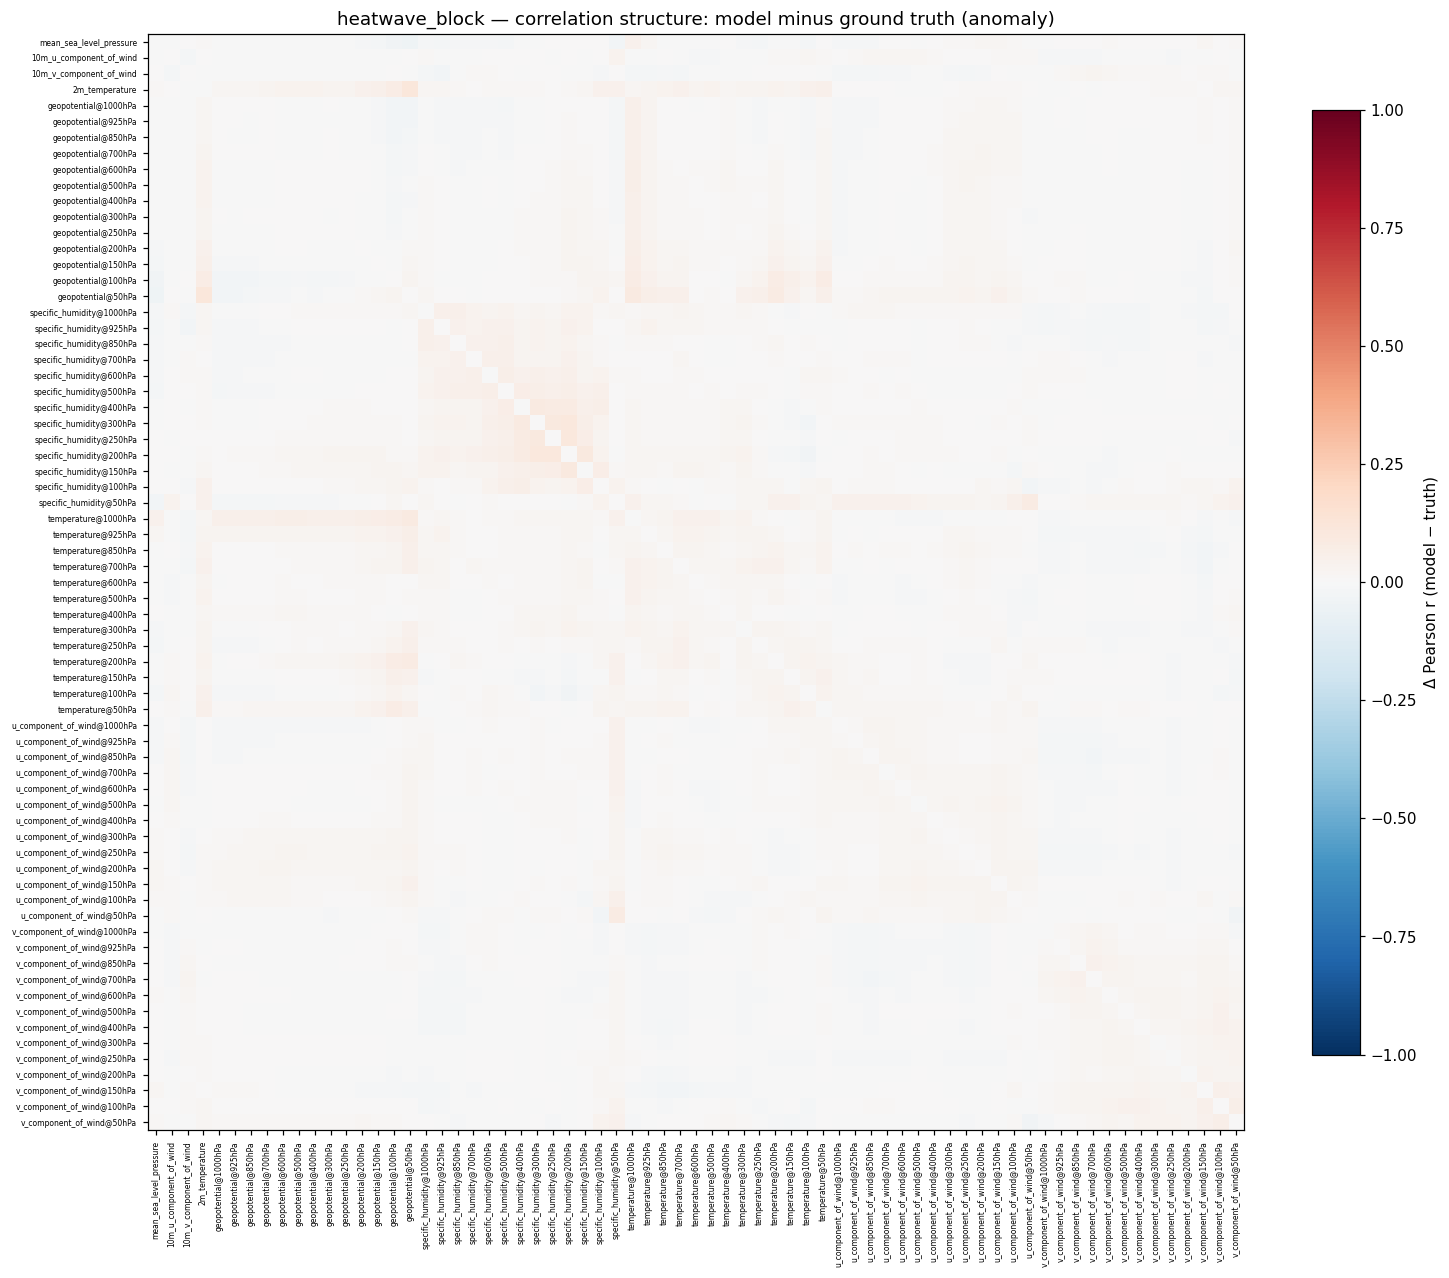

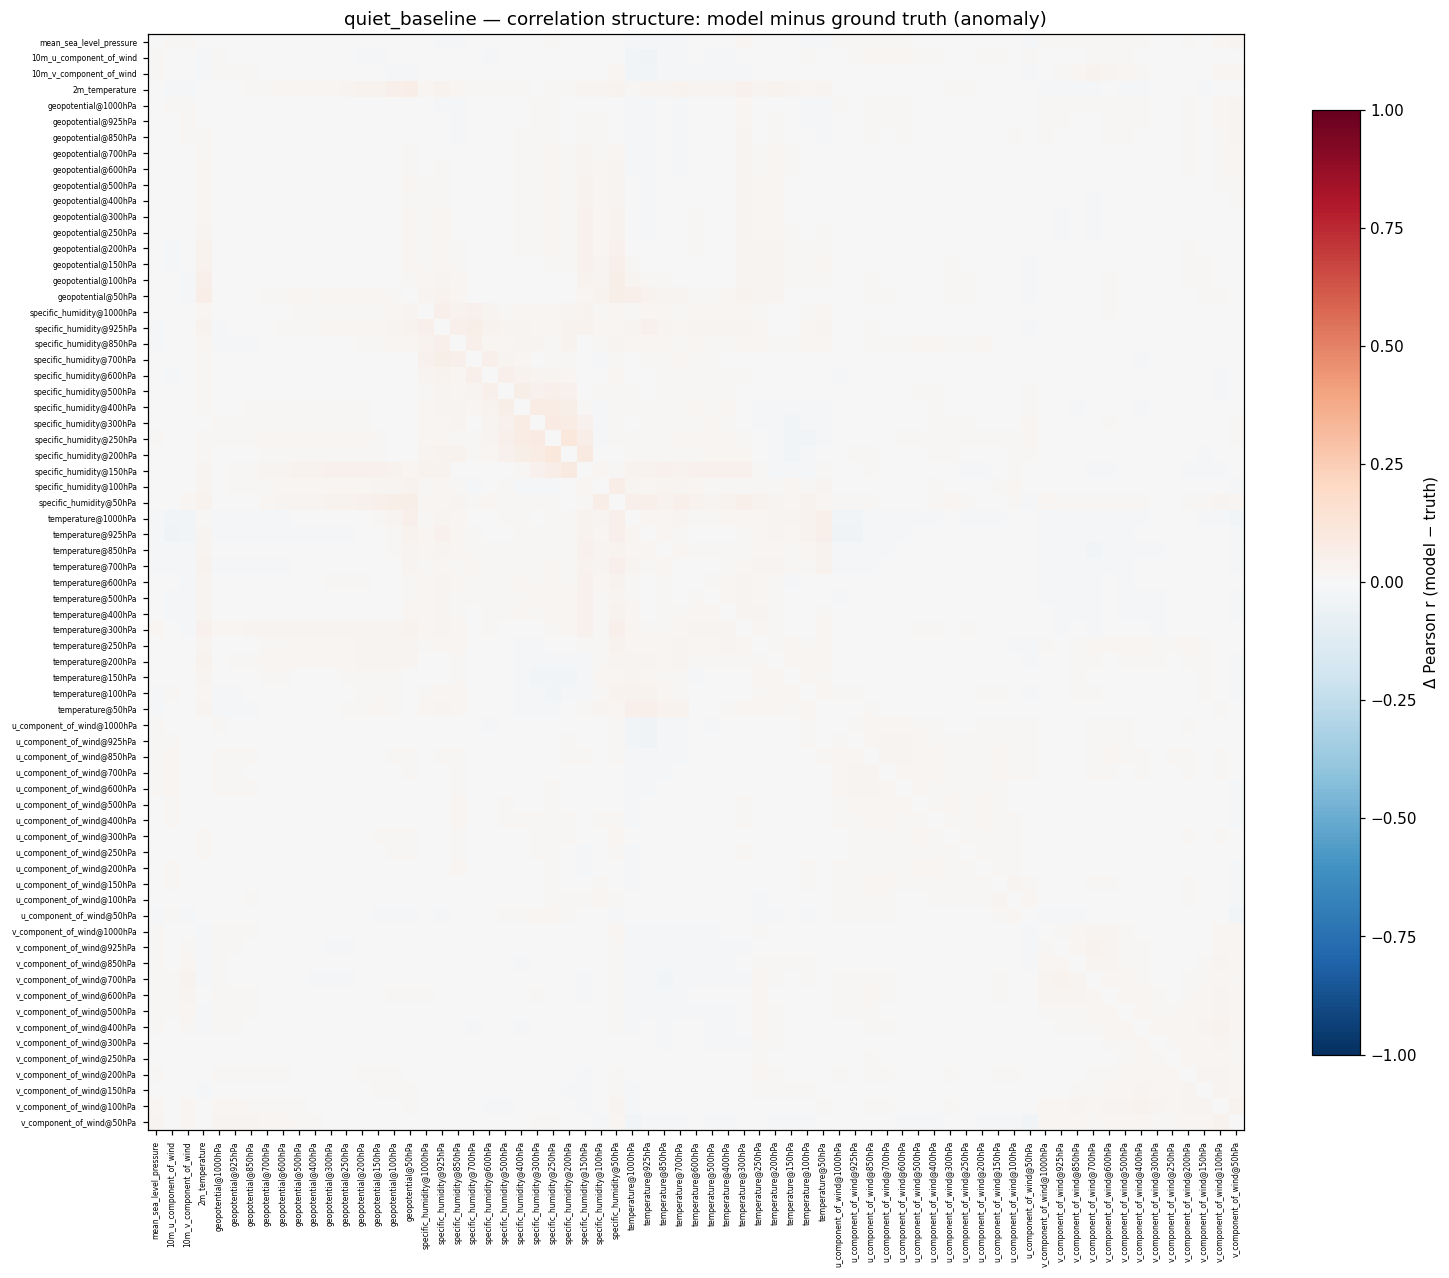

In [6]:
def plot_corr_diff(case, mode):
    res = correlation_results[case]
    diff = res[f'model_{mode}'] - res[f'truth_{mode}']

    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(diff, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(CHANNEL_LABELS)))
    ax.set_yticks(range(len(CHANNEL_LABELS)))
    ax.set_xticklabels(CHANNEL_LABELS, rotation=90, fontsize=5)
    ax.set_yticklabels(CHANNEL_LABELS, fontsize=5)
    plt.colorbar(im, ax=ax, shrink=0.8, label='Δ Pearson r (model − truth)')
    ax.set_title(f'{case} — correlation structure: model minus ground truth ({mode})')
    plt.tight_layout()
    plt.savefig(f'figures/{case}_corr_diff_{mode}.png', dpi=150, bbox_inches='tight')
    plt.show()


for case in CASES:
    plot_corr_diff(case, 'anomaly')


## 5. Локальные пространственные карты корреляции

Один снимок времени → нет временной оси для классической point-wise time-correlation. Вместо неё считаем
**локальную пространственную корреляцию** (Pearson r между значениями двух переменных внутри скользящего окна,
по пикселям — не по времени). Показывает, где два поля локально согласованно меняются в пространстве.

Пары:
- **MSLP vs Z@500hPa** — оба прокси одного и того же крупномасштабного барического поля, ожидаем сильную
  положительную корреляцию почти везде
- **Z@500hPa vs T@850hPa** — термический ветер / связь mощности слоя с температурой — ожидаем выраженную
  корреляцию в бароклинных зонах (фронты, струйное течение), слабее в тропиках


**Известное ограничение метода**: local spatial correlation получилась шумной/шахматной (проверено и признано известным артефактом, не багом для доисправления). Причина — маленькое окно (40x40 точек) на гладких квазилинейных полях даёт нестабильную оценку Pearson r: локальный наклон/фазовый сдвиг бароклинного поля с высотой доминирует над реальной совместной вариацией. Метод одного снимка (без временного ряда) для локальной корреляции в принципе шумный. Основной, надёжный результат — **глобальная корреляционная матрица** (разделы 3-4), она физически осмысленна (блочная структура: geopotential когерентен по уровням, humidity — свой блок, temperature — тропосфера/стратосфера, u/v — раздельные баротропные блоки).

In [7]:
PATCH_SIZE = 40
STRIDE = 40


def local_spatial_corr(field_a, field_b, patch_size=PATCH_SIZE, stride=STRIDE):
    n_lat, n_lon = field_a.shape
    corr_map = np.full((n_lat, n_lon), np.nan, dtype=np.float32)
    for lat0 in range(0, n_lat, stride):
        lat1 = min(lat0 + patch_size, n_lat)
        for lon0 in range(0, n_lon, stride):
            lon1 = min(lon0 + patch_size, n_lon)
            a = field_a[lat0:lat1, lon0:lon1].ravel()
            b = field_b[lat0:lat1, lon0:lon1].ravel()
            if np.std(a) > 1e-6 and np.std(b) > 1e-6:
                r = np.corrcoef(a, b)[0, 1]
            else:
                r = 0.0
            corr_map[lat0:lat1, lon0:lon1] = r
    return corr_map


def get_channel(fields_2d_dict_output_surface_upper, name):
    """Extract a single 2D (721,1440) field from the raw output_surface/output_upper pair by label."""
    out_surf, out_upp = fields_2d_dict_output_surface_upper
    if name in SURFACE_ORDER:
        return out_surf[SURFACE_ORDER.index(name)]
    var, lvl = name.split('@')
    lvl = int(lvl.replace('hPa', ''))
    return out_upp[UPPER_ORDER.index(var)][PRESSURE_LEVELS_HPA.index(lvl)]


PAIRS = [
    ('mean_sea_level_pressure', 'geopotential@500hPa'),
    ('geopotential@500hPa', 'temperature@850hPa'),
]

local_corr_maps = {}
for case in CASES:
    baseline = case_results[case]['baseline_output']
    for var_a, var_b in PAIRS:
        field_a = get_channel(baseline, var_a)
        field_b = get_channel(baseline, var_b)
        local_corr_maps[(case, var_a, var_b)] = local_spatial_corr(field_a, field_b)
    print(f'{case}: local correlation maps done.')


storm_eunice: local correlation maps done.


heatwave_block: local correlation maps done.
quiet_baseline: local correlation maps done.


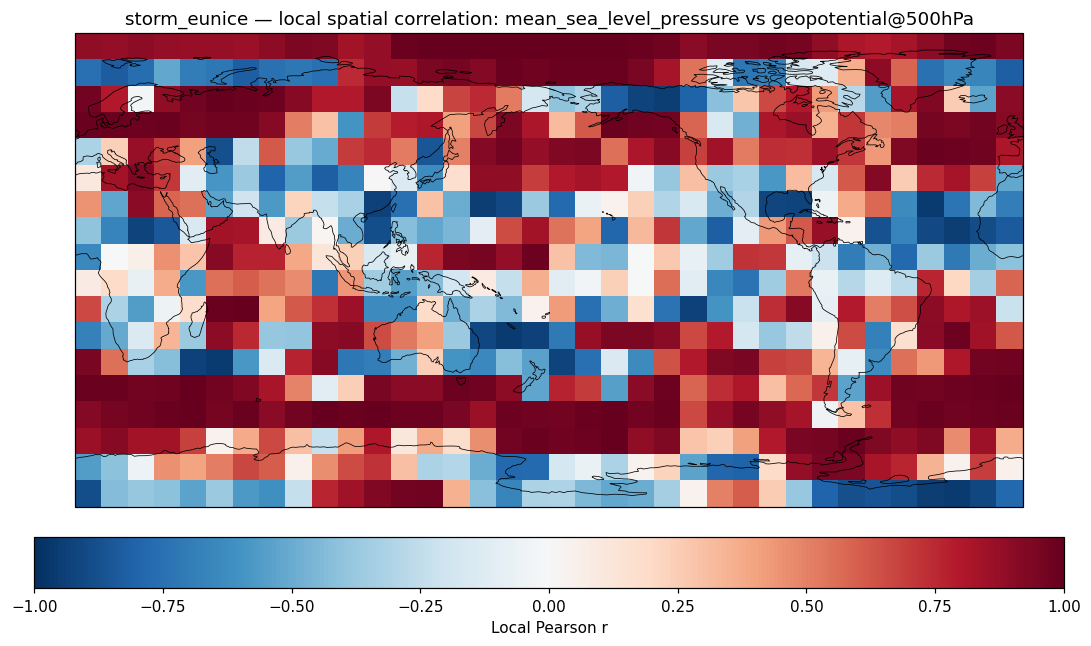

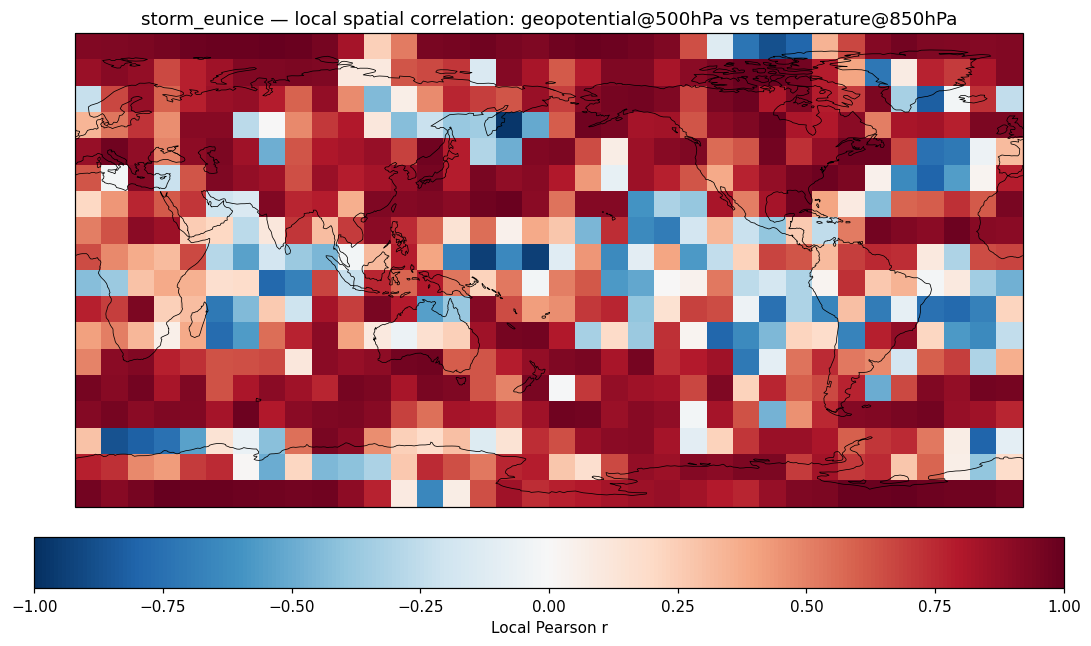

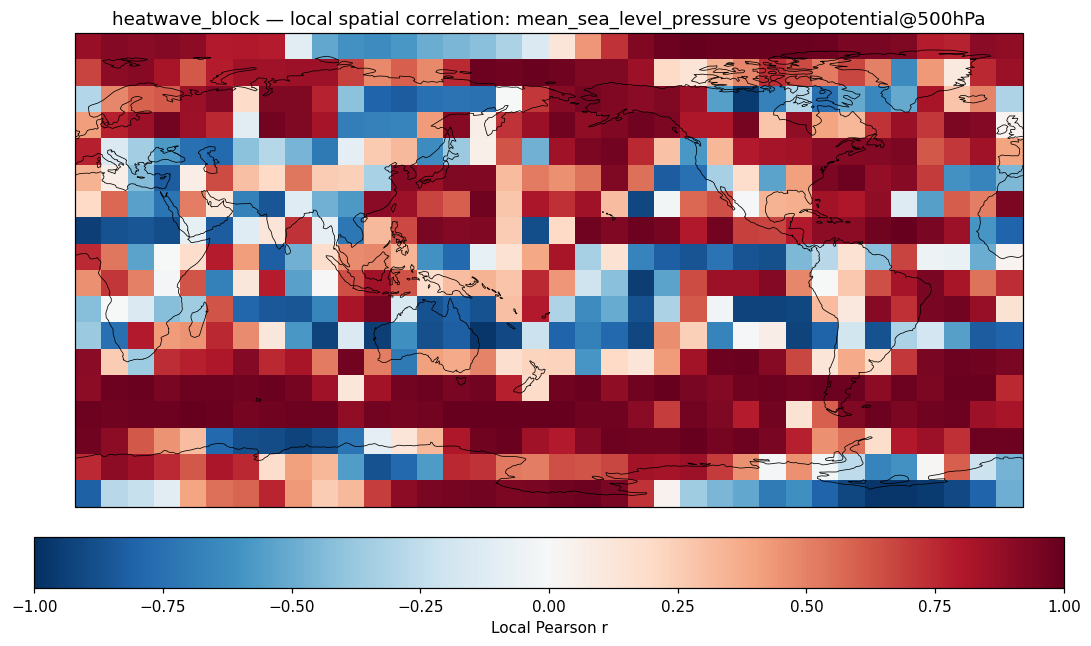

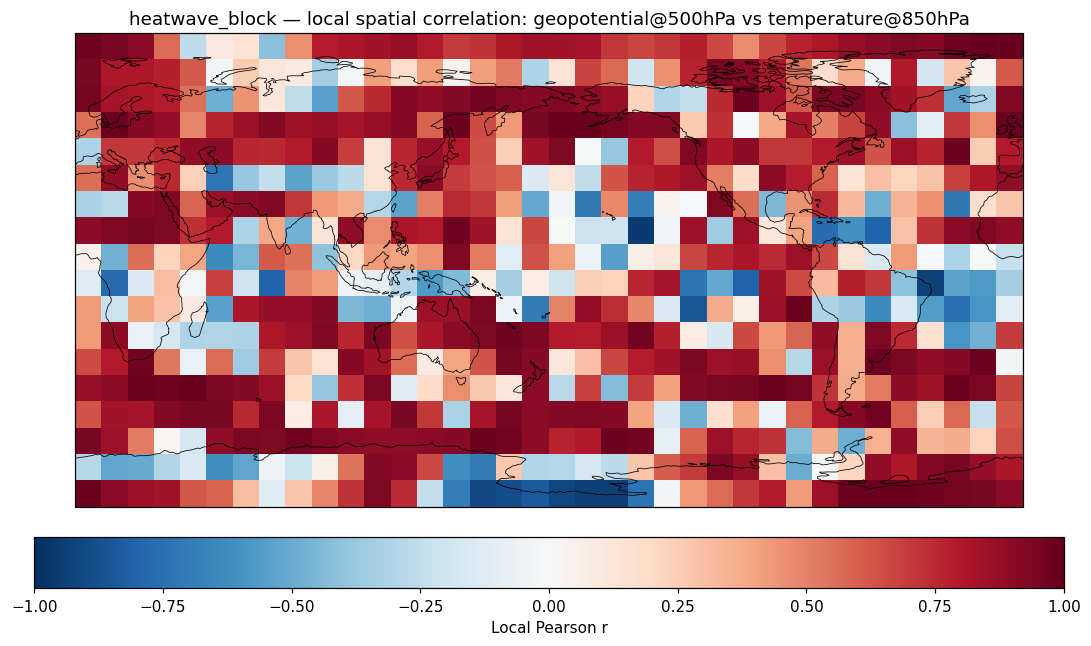

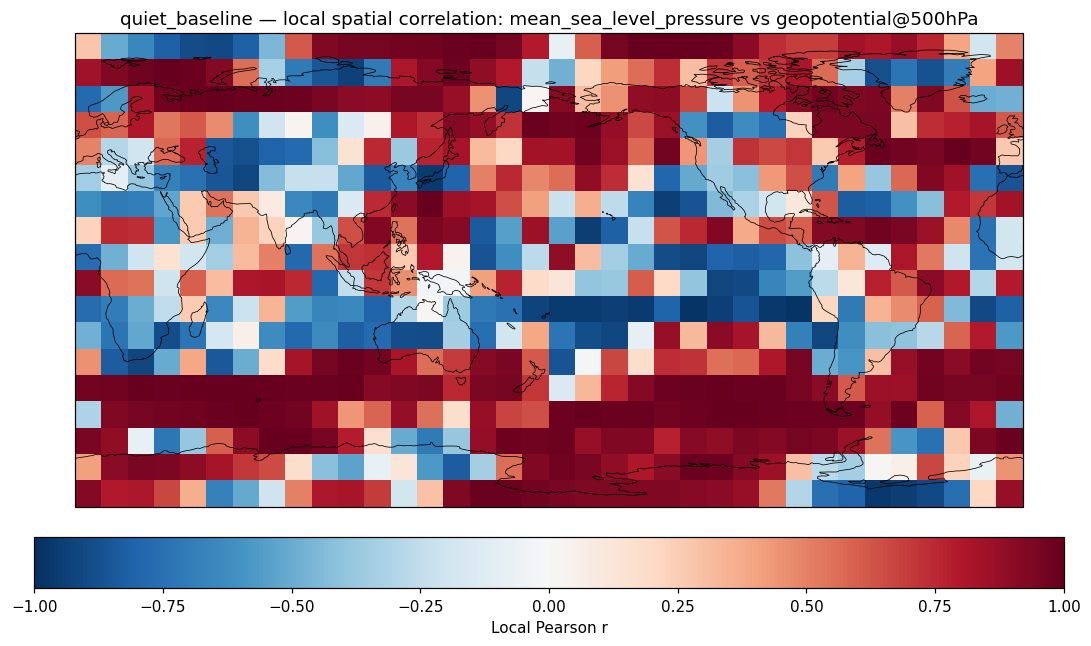

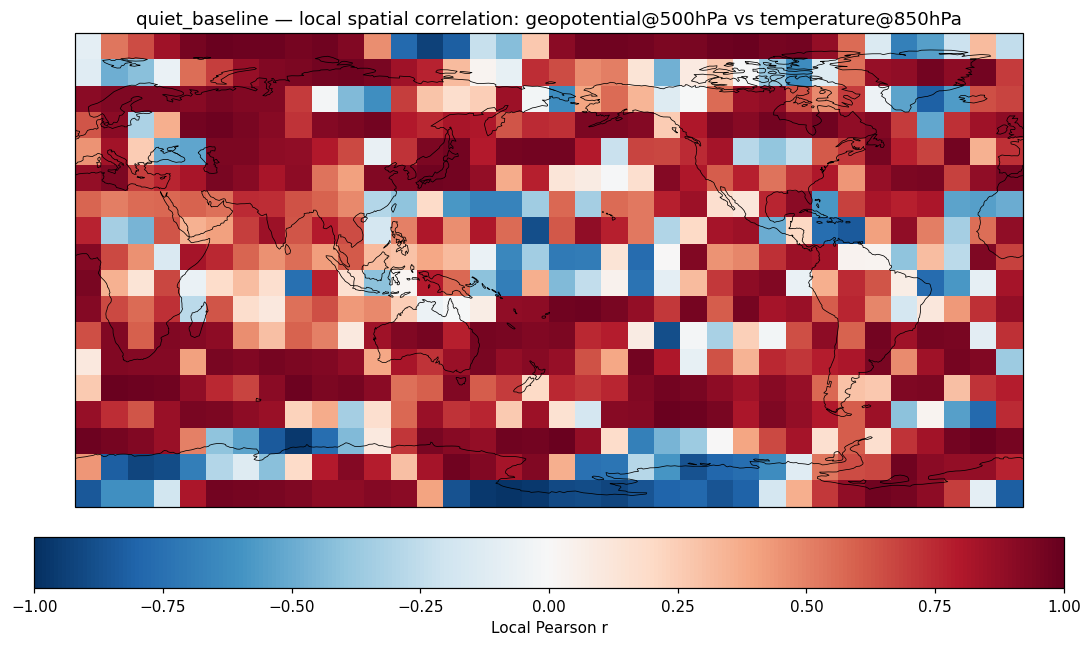

In [8]:
def plot_local_corr(case, var_a, var_b):
    corr_map = local_corr_maps[(case, var_a, var_b)]
    lats = np.linspace(90, -90, 721)
    lons = np.linspace(0, 359.75, 1440)

    fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
    ax.set_global()
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    im = ax.pcolormesh(lons, lats, corr_map, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8, label='Local Pearson r')
    ax.set_title(f'{case} — local spatial correlation: {var_a} vs {var_b}')
    plt.tight_layout()
    safe_name = f'{var_a}_vs_{var_b}'.replace('@', '_')
    plt.savefig(f'figures/{case}_local_corr_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


for case in CASES:
    for var_a, var_b in PAIRS:
        plot_local_corr(case, var_a, var_b)


## 6. Наблюдения

- **Глобальная корреляционная матрица (основной результат)**: физически осмысленна — geopotential когерентен по всем 13 уровням (сплошной блок), MSLP сильно коррелирует с ним, specific_humidity формирует свой блок, temperature — два блока (тропосфера/стратосфера), u/v компоненты ветра — раздельные когерентные по высоте блоки (баротропная структура). Совпадает с ожидаемой атмосферной физикой.
- **Local spatial correlation — известное ограничение метода** (см. раздел 5), не интерпретируется как физический сигнал в текущей форме.
- Сравнение модель vs ground truth (раздел 4) — см. `*_corr_diff_anomaly.png` для каждого кейса.